In [377]:
import numpy as np
!pip install qiskit
from qiskit import QuantumCircuit
from scipy.optimize import minimize
!pip install pylatexenc

In [378]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize
from sklearn.datasets import load_iris
import seaborn as sns
import pandas as pd

In [379]:
data = load_iris()
X = data.data
Y = data.target

X.shape, Y.shape

((150, 4), (150,))

In [380]:
CLASS_SETOSA = 0
CLASS_VERSICOLOR = 1
CLASS_VIRGINICA = 2

# Swap these two to test any pair
CLASS_A = CLASS_VIRGINICA
CLASS_B = CLASS_VERSICOLOR

mask = (Y == CLASS_A) | (Y == CLASS_B)
X = X[mask]
Y = Y[mask]


Text(0.5, 1.02, 'Iris — all 3 classes, all feature pairs')

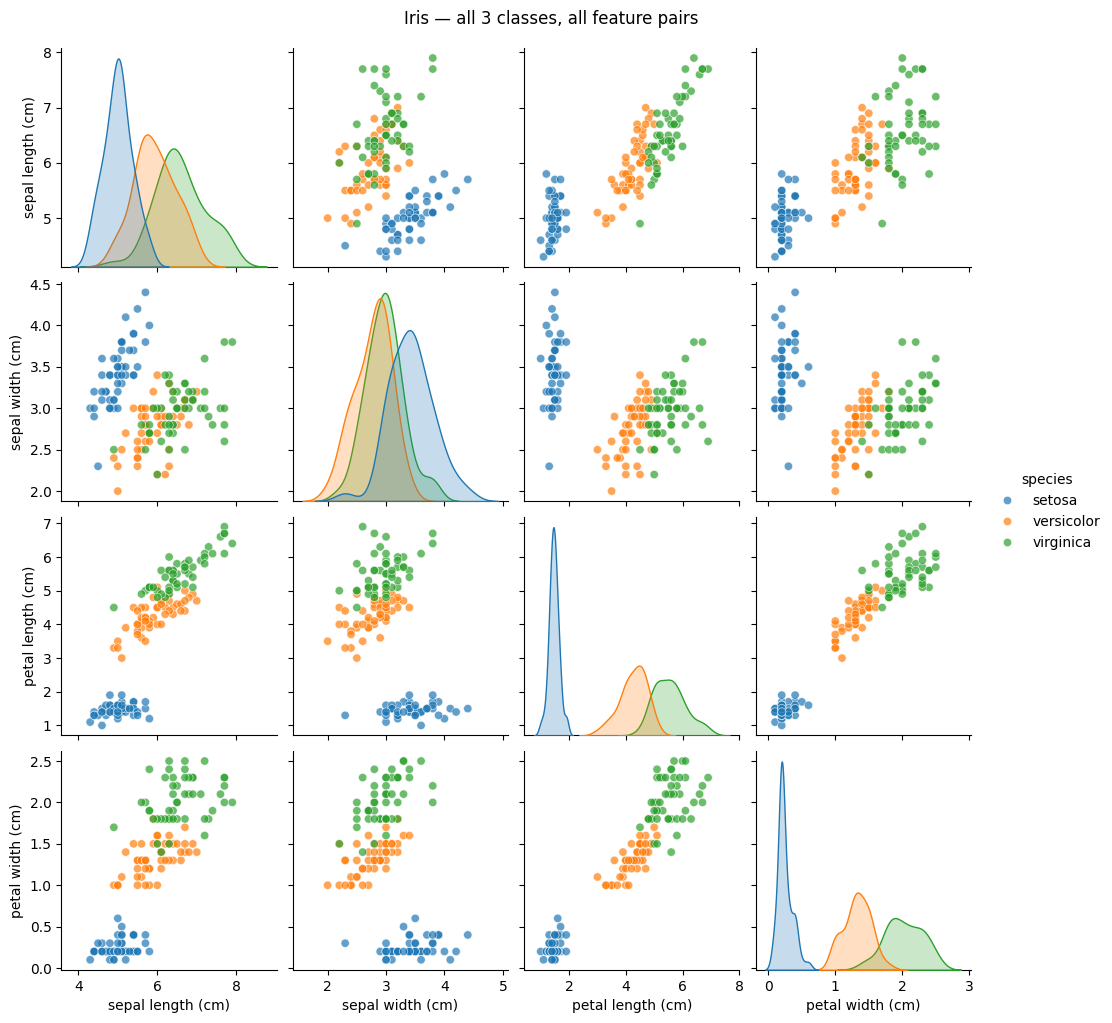

In [381]:
df_full = pd.DataFrame(data.data, columns=data.feature_names)
df_full["species"] = [data.target_names[v] for v in data.target]

g = sns.pairplot(df_full, hue="species", plot_kws={"alpha": 0.7})
g.fig.suptitle("Iris — all 3 classes, all feature pairs", y=1.02)


In [382]:
Y = np.where(Y == CLASS_A, 1, -1)

In [383]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)
X_train = (X_train - X_min) / (X_max - X_min)
X_test  = (X_test  - X_min) / (X_max - X_min)

In [384]:
SEPAL_LENGTH = 0
SEPAL_WIDTH  = 1
PETAL_LENGTH = 2
PETAL_WIDTH  = 3

FEATURE_A = PETAL_LENGTH
FEATURE_B = PETAL_WIDTH

def encode(x):
    qc = QuantumCircuit(2)
    qc.ry(np.pi * x[FEATURE_A], 0)
    qc.ry(np.pi * x[FEATURE_B], 1)
    return qc


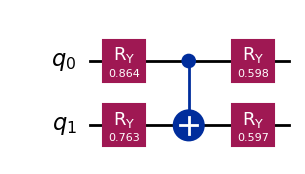

In [385]:
# 2 params per layer + 2 final = 2*N_LAYERS+2 total params
N_LAYERS = 1

def entangling_layer(qc, theta, theta_offset):
    qc.ry(theta[theta_offset + 0], 0)
    qc.ry(theta[theta_offset + 1], 1)
    qc.cx(0, 1)

def classifier_head(qc, theta):
    qc.ry(theta[-2], 0)
    qc.ry(theta[-1], 1)

def ansatz(theta):
    qc = QuantumCircuit(2)
    for l in range(N_LAYERS):
        entangling_layer(qc, theta, theta_offset=l * 2)
    classifier_head(qc, theta)
    return qc

theta_demo = np.random.rand(2 * N_LAYERS + 2)
qc_ansatz = ansatz(theta_demo)
qc_ansatz.draw(output="mpl")


In [386]:
def build_circuit(x, theta):
    qc = QuantumCircuit(2)
    qc.compose(encode(x), inplace=True)
    qc.compose(ansatz(theta), inplace=True)
    return qc


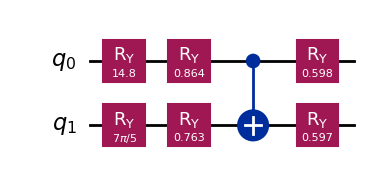

In [387]:
qc_full = build_circuit(X[0], theta_demo)
qc_full.draw(output="mpl")

In [388]:
def forward(x, theta):
    qc = build_circuit(x, theta)
    state = Statevector.from_instruction(qc)
    return float(np.real(state.expectation_value([[1, 0], [0, -1]], [0])))


In [389]:
def loss(theta, X, Y):
    preds = np.array([forward(xi, theta) for xi in X])
    return np.mean((preds - Y) ** 2)


In [390]:
result = minimize(loss, np.random.rand(2 * N_LAYERS + 2), args=(X_train, Y_train), method='COBYLA')
theta_opt = result.x

print("Optimized theta:", theta_opt)
print("Final loss:", result.fun)


Optimized theta: [ 0.08978084  1.67257234  2.36621457 -0.17418555]
Final loss: 0.20815578199724588


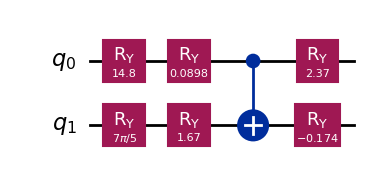

In [391]:
qc_trained = build_circuit(X[0], theta_opt)
qc_trained.draw(output="mpl")

In [392]:
pred_labels_test = np.array([
    1 if forward(x, theta_opt) >= 0 else -1
    for x in X_test
])

accuracy_test = np.mean(pred_labels_test == Y_test)

print("Test Accuracy:", accuracy_test)


Test Accuracy: 0.9


In [393]:
pred_labels_train = np.array([
    1 if forward(x, theta_opt) >= 0 else -1
    for x in X_train
])

accuracy_train = np.mean(pred_labels_train == Y_train)

print("Train Accuracy:", accuracy_train)


Train Accuracy: 0.95


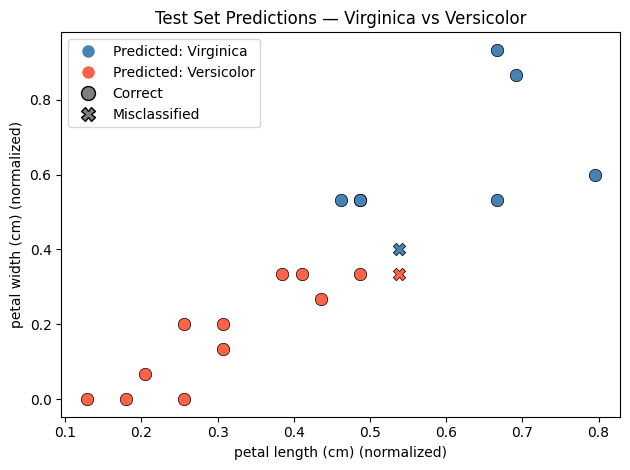

In [394]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots()
colors = {1: "steelblue", -1: "tomato"}

feature_labels = data.feature_names
class_a_name = data.target_names[CLASS_A].capitalize()
class_b_name = data.target_names[CLASS_B].capitalize()

for xi, y_true, y_pred in zip(X_test, Y_test, pred_labels_test):
    marker = "o" if y_true == y_pred else "X"
    ax.scatter(xi[FEATURE_A], xi[FEATURE_B], c=colors[y_pred], marker=marker,
               edgecolors="k", linewidths=0.5, s=80)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=10, label=f"Predicted: {class_a_name}"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="tomato",    markersize=10, label=f"Predicted: {class_b_name}"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markeredgecolor="k", markersize=10, label="Correct"),
    Line2D([0], [0], marker="X", color="w", markerfacecolor="gray", markeredgecolor="k", markersize=10, label="Misclassified"),
]
ax.legend(handles=legend_elements)
ax.set_xlabel(feature_labels[FEATURE_A] + " (normalized)")
ax.set_ylabel(feature_labels[FEATURE_B] + " (normalized)")
ax.set_title(f"Test Set Predictions — {class_a_name} vs {class_b_name}")
plt.tight_layout()
plt.show()


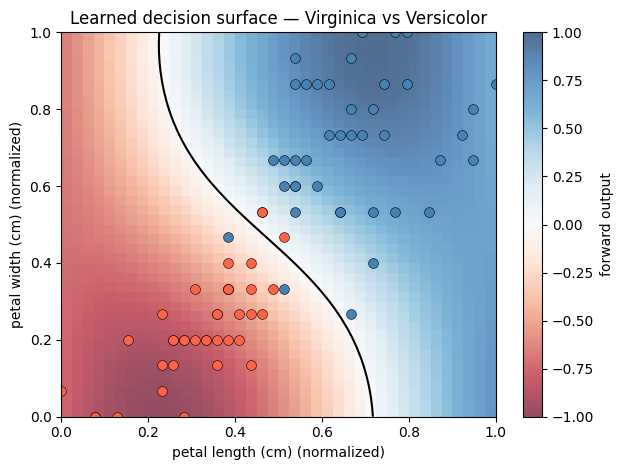

In [395]:
resolution = 40
grid = np.linspace(0, 1, resolution)
g0, g1 = np.meshgrid(grid, grid)

x_proto = np.zeros(X_train.shape[1])

Z_values = []
for a, b in zip(g0.ravel(), g1.ravel()):
    x_temp = x_proto.copy()
    x_temp[FEATURE_A] = a
    x_temp[FEATURE_B] = b
    Z_values.append(forward(x_temp, theta_opt))

Z = np.array(Z_values).reshape(resolution, resolution)

fig, ax = plt.subplots()
im = ax.imshow(Z, extent=[0, 1, 0, 1], origin="lower", cmap="RdBu", vmin=-1, vmax=1, aspect="auto", alpha=0.7)
ax.contour(g0, g1, Z, levels=[0], colors="k", linewidths=1.5)
plt.colorbar(im, ax=ax, label="forward output")

for xi, yi in zip(X_train[:, [FEATURE_A, FEATURE_B]], Y_train):
    ax.scatter(xi[0], xi[1], c="steelblue" if yi == 1 else "tomato", edgecolors="k", linewidths=0.4, s=50)

ax.set_xlabel(feature_labels[FEATURE_A] + " (normalized)")
ax.set_ylabel(feature_labels[FEATURE_B] + " (normalized)")
ax.set_title(f"Learned decision surface — {class_a_name} vs {class_b_name}")
plt.tight_layout()
plt.show()


In [396]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(2,), activation='tanh', max_iter=1000, random_state=42)
mlp.fit(X_train[:, [FEATURE_A, FEATURE_B]], Y_train)

print("Classical MLP Train Accuracy:", np.mean(mlp.predict(X_train[:, [FEATURE_A, FEATURE_B]]) == Y_train))
print("Classical MLP Test Accuracy: ", np.mean(mlp.predict(X_test[:, [FEATURE_A, FEATURE_B]])  == Y_test))
print()
print("VQC        Train Accuracy:", accuracy_train)
print("VQC        Test Accuracy: ", accuracy_test)


Classical MLP Train Accuracy: 0.9625
Classical MLP Test Accuracy:  0.95

VQC        Train Accuracy: 0.95
VQC        Test Accuracy:  0.9


d:\dev\repos\Variational-Quantum-Classifier\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [397]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train[:, [FEATURE_A, FEATURE_B]], Y_train)

print("SVM (RBF) Train Accuracy:", np.mean(svm.predict(X_train[:, [FEATURE_A, FEATURE_B]]) == Y_train))
print("SVM (RBF) Test Accuracy: ", np.mean(svm.predict(X_test[:, [FEATURE_A, FEATURE_B]])  == Y_test))
print()
print("VQC       Train Accuracy:", accuracy_train)
print("VQC       Test Accuracy: ", accuracy_test)


SVM (RBF) Train Accuracy: 0.95
SVM (RBF) Test Accuracy:  0.95

VQC       Train Accuracy: 0.95
VQC       Test Accuracy:  0.9


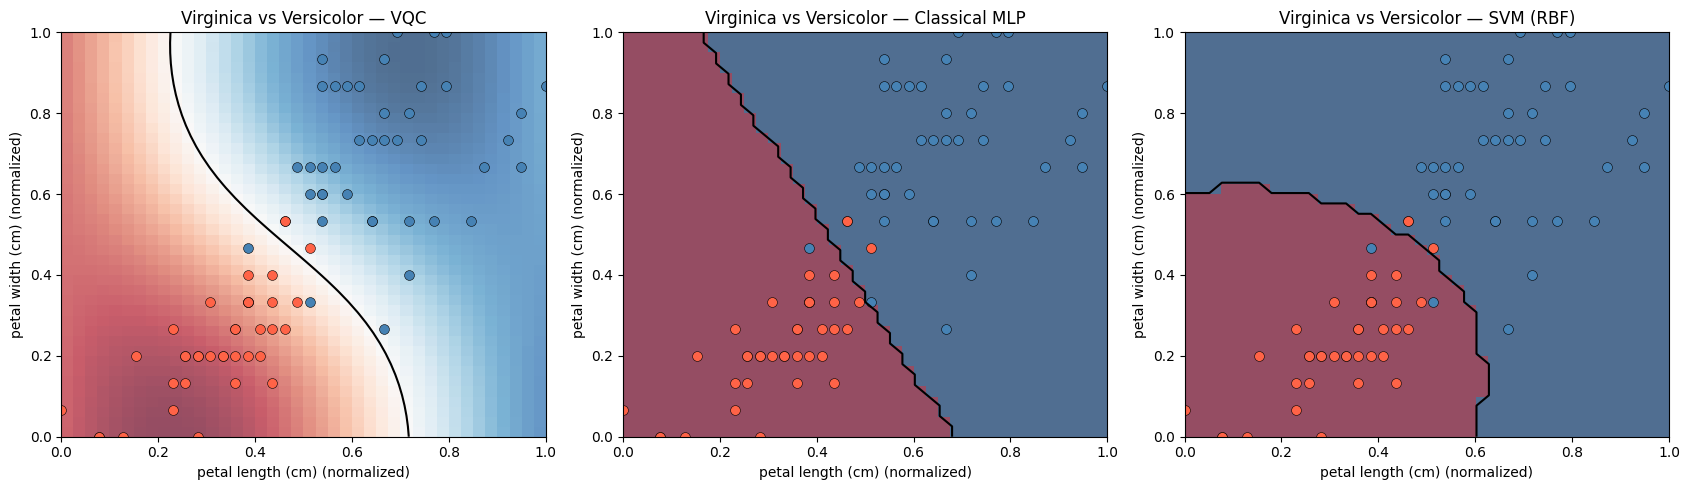

In [ ]:
resolution = 40
grid = np.linspace(0, 1, resolution)
g0, g1 = np.meshgrid(grid, grid)
grid_2d = np.column_stack([g0.ravel(), g1.ravel()])

x_proto = np.zeros(X_train.shape[1])
Z_vqc_values = []
for a, b in zip(g0.ravel(), g1.ravel()):
    x_temp = x_proto.copy()
    x_temp[FEATURE_A] = a
    x_temp[FEATURE_B] = b
    Z_vqc_values.append(forward(x_temp, theta_opt))
Z_vqc = np.array(Z_vqc_values).reshape(resolution, resolution)

# Use continuous scores so all three plots render with gradients like the VQC
Z_mlp = (mlp.predict_proba(grid_2d)[:, 1] * 2 - 1).reshape(resolution, resolution)
Z_svm = svm.decision_function(grid_2d).reshape(resolution, resolution)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_map = {1: "steelblue", -1: "tomato"}

for ax, Z, title in zip(axes, [Z_vqc, Z_mlp, Z_svm], ["VQC", "Classical MLP", "SVM (RBF)"]):
    ax.imshow(Z, extent=[0, 1, 0, 1], origin="lower", cmap="RdBu", vmin=-1, vmax=1, aspect="auto", alpha=0.7)
    ax.contour(g0, g1, Z, levels=[0], colors="k", linewidths=1.5)
    for xi, yi in zip(X_train[:, [FEATURE_A, FEATURE_B]], Y_train):
        ax.scatter(xi[0], xi[1], c=colors_map[yi], edgecolors="k", linewidths=0.4, s=50)
    ax.set_xlabel(feature_labels[FEATURE_A] + " (normalized)")
    ax.set_ylabel(feature_labels[FEATURE_B] + " (normalized)")
    ax.set_title(f"{class_a_name} vs {class_b_name} — {title}")

plt.tight_layout()
plt.show()
